In [6]:
from typing import Any
from typing import Self

from collections import deque

import numpy as np
import networkx as nx

np.random.seed(42)

In [7]:
class Node:
    def __init__(self, pos: tuple[int, int], data: Any):
        self.pos = pos
        self.data = data
        self.neighbors: list[Node] = []
        self.visited: bool = False
        self.parent: Node | None = None

    def connect(self, other: Self) -> None:
        if other not in self.neighbors:
            self.neighbors.append(other)
            other.neighbors.append(self)

    def __repr__(self) -> str:
        return f"{self.pos}{len(self.neighbors)}{'+' if self.visited else '-'}"

    def __str__(self) -> str:
        return repr(self)

    def __len__(self) -> None:
        return len(self.neighbors)

In [8]:
class Labyrinth:
    def __init__(self, height: int, width: int, alpha: float = 0.6):
        self.height = height
        self.width = width
        self.nodes: dict[tuple[int, int], Node] = {}
        self.alpha = alpha

    def generate(self) -> None:
        for i in range(self.height):
            for j in range(self.width):
                node = Node(pos=(i, j), data=i * self.width + j)
                self.nodes[node.pos] = node

        for h in range(1, self.height):
            if np.random.rand() < self.alpha:
                self.nodes[(h, 0)].connect(self.nodes[(h - 1, 0)])
        for w in range(1, self.width):
            if np.random.rand() < self.alpha:
                self.nodes[(0, w)].connect(self.nodes[(0, w - 1)])
        for h in range(1, self.height):
            for w in range(1, self.width):
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h, w - 1)])
                if np.random.rand() < self.alpha:
                    self.nodes[(h, w)].connect(self.nodes[(h - 1, w)])

        self.root = self.nodes[(0, 0)]

    def to_nx(self) -> nx.DiGraph:
        g = nx.Graph(data=None)
        pos = {}

        for node in self.nodes.values():
            g.add_node(node.pos, data=node.data)
            pos[node.pos] = node.pos

            for neighbor in node.neighbors:
                if neighbor.pos[0] <= node.pos[0] or neighbor.pos[1] <= node.pos[1]:
                    g.add_edge(node.pos, neighbor.pos)

        return g, pos

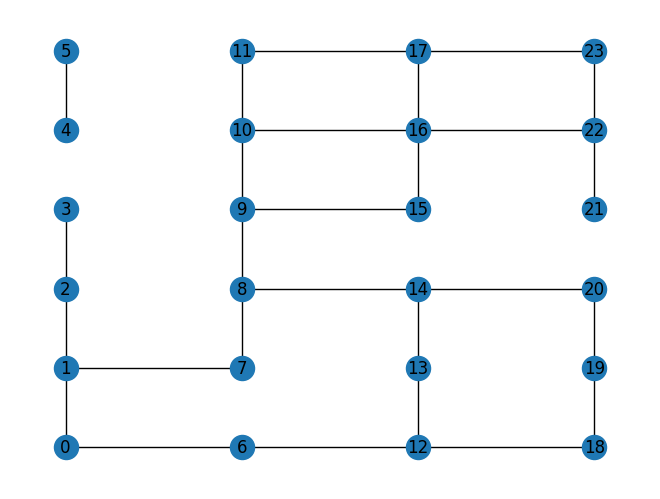

In [30]:
HEIGHT, WIDTH = 4, 6
ALPHA = 0.7

lab = Labyrinth(height=HEIGHT, width=WIDTH, alpha=ALPHA)

lab.generate()

g, pos = lab.to_nx()

nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos)

In [31]:
stack = deque()
stack.append(("a", 1))
stack.append(("b", 2))
stack.append(("c", -2))
stack.append(("d", 10))
sorted_stack = deque(sorted(stack, key=lambda x: x[1]))
sorted_stack, type(sorted_stack)

(deque([('c', -2), ('a', 1), ('b', 2), ('d', 10)]), collections.deque)

In [32]:
def algorithm_A_iterative(root: Node, target: Node):
    stack = deque([(root, 0)])

    while len(stack) > 0:
        node, cost = stack.pop()
        print(f"{node=}, {cost=} {len(stack)=}")
        if not node.visited:
            node.visited = True
            if node == target:
                return True
            else:
                next_nodes = [n for n in node.neighbors if not n.visited]
                print(next_nodes)
                if len(next_nodes) == 0:
                    stack = deque(sorted(stack, key=lambda x: x[1]))
                    continue
                else:
                    for n in next_nodes:
                        n.parent = node
                        stack.append(
                            (
                                n,
                                cost + 1,
                            )
                        )

    return False


for node in lab.nodes.values():
    node.visited = False
    node.parent = None

root = lab.nodes[0, 0]
target = lab.nodes[0, 3]
result = algorithm_A_iterative(root=root, target=target)
result

node=(0, 0)2-, cost=0 len(stack)=0
[(1, 0)2-, (0, 1)3-]
node=(0, 1)3-, cost=1 len(stack)=1
[(0, 2)2-, (1, 1)2-]
node=(1, 1)2-, cost=2 len(stack)=2
[(1, 2)3-]
node=(1, 2)3-, cost=3 len(stack)=2
[(1, 3)3-, (2, 2)3-]
node=(2, 2)3-, cost=4 len(stack)=3
[(2, 1)2-, (3, 2)2-]
node=(3, 2)2-, cost=5 len(stack)=4
[(3, 1)2-]
node=(3, 1)2-, cost=6 len(stack)=4
[(3, 0)2-]
node=(3, 0)2-, cost=7 len(stack)=4
[(2, 0)3-]
node=(2, 0)3-, cost=8 len(stack)=4
[(1, 0)2-, (2, 1)2-]
node=(2, 1)2-, cost=9 len(stack)=5
[]
node=(1, 0)2-, cost=9 len(stack)=4
[]
node=(2, 1)2+, cost=5 len(stack)=3
node=(1, 3)3-, cost=4 len(stack)=2
[(1, 4)3-, (2, 3)2-]
node=(2, 3)2-, cost=5 len(stack)=3
[(2, 4)4-]
node=(2, 4)4-, cost=6 len(stack)=3
[(1, 4)3-, (2, 5)3-, (3, 4)3-]
node=(3, 4)3-, cost=7 len(stack)=5
[(3, 3)1-, (3, 5)2-]
node=(3, 5)2-, cost=8 len(stack)=6
[(2, 5)3-]
node=(2, 5)3-, cost=9 len(stack)=6
[(1, 5)2-]
node=(1, 5)2-, cost=10 len(stack)=6
[(1, 4)3-]
node=(1, 4)3-, cost=11 len(stack)=6
[]
node=(3, 3)1-, cost=8 l

True

In [33]:
current = target
path = [current.pos]
while current.parent is not None:
    current = current.parent
    path.append(current.pos)

path

[(0, 3), (0, 2), (0, 1), (0, 0)]

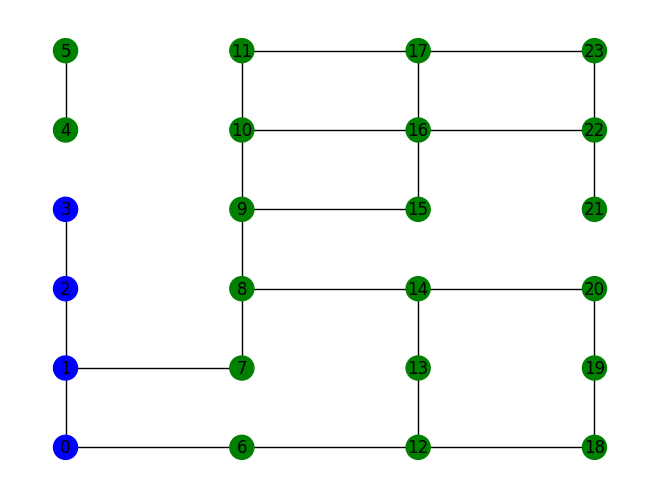

In [34]:
color_map = []
for node in g:
    if node in path:
        color_map.append("blue")
    else:
        color_map.append("green")
nx.draw(g, labels=nx.get_node_attributes(g, "data"), pos=pos, node_color=color_map)